<a href="https://colab.research.google.com/github/akwve/STA160_Group2_Project/blob/main/Url_Xgb_ChatGPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

from google.colab import files
uploaded = files.upload()

Saving fake_true_news_data.txt to fake_true_news_data.txt


In [2]:
import pandas as pd

df = pd.read_csv("fake_true_news_data.txt")
df['all_words'] = df['title'].astype(str) + ' ' + df['text'].astype(str)
df.head()


,title,text,subject,date,year,label,all_words
0,donald trump sends out embarrassing new year’s...,donald trump wish american happy new year leav...,News,2017-12-31,2017.0,False,donald trump sends out embarrassing new year’s...
1,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...,News,2017-12-31,2017.0,False,drunk bragging trump staffer started russian c...
2,sheriff david clarke becomes an internet joke ...,friday revealed former milwaukee sheriff david...,News,2017-12-30,2017.0,False,sheriff david clarke becomes an internet joke ...
3,trump is so obsessed he even has obama’s name ...,christmas day donald trump announced would bac...,News,2017-12-29,2017.0,False,trump is so obsessed he even has obama’s name ...
4,pope francis just called out donald trump duri...,pope francis used annual christmas day message...,News,2017-12-25,2017.0,False,pope francis just called out donald trump duri...


In [3]:
from sklearn.model_selection import train_test_split
X = df[['all_words']]
y = df['label']

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=12234, stratify=y)


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report

vect = TfidfVectorizer()
X_train_tfidf = vect.fit_transform(X_train['all_words'])
X_test_tfidf = vect.transform(X_test['all_words'])


def train(model ,model_name ,X_train ,y_train ,X_test ,y_test):
    model.fit(X_train,y_train)
    model_train_score = model.score(X_train,y_train)
    model_test_score = model.score(X_test,y_test)
    print(f"{model_name} Training data accuracy: {model_train_score * 100}%\n{model_name} Testing data accuracy: {model_test_score * 100}%")

def class_report(model ,X_test , y_test):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=['Fake', 'True']))

vect = TfidfVectorizer()
X_train_tfidf = vect.fit_transform(X_train['all_words'])
X_test_tfidf = vect.transform(X_test['all_words'])

In [5]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import  ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC


lr = LogisticRegression()
train(lr,"Logistic Regression", X_train_tfidf, Y_train, X_test_tfidf, Y_test)

xgboost = model = XGBClassifier(objective = "binary:logistic" , subsample = 0.6 , min_child_weight = 3,
                                max_depth = 3 , learning_rate = 0.1 , gamma = 0 , colsample_bytree = 0.5,)
train(xgboost,"Xgboost", X_train_tfidf, Y_train, X_test_tfidf, Y_test)

svc = LinearSVC()
train(svc, "Linear SVC", X_train_tfidf, Y_train, X_test_tfidf, Y_test)



Logistic Regression Training data accuracy: 99.20281950155241%
Logistic Regression Testing data accuracy: 98.86999328708883%
Xgboost Training data accuracy: 99.68951917428883%
Xgboost Testing data accuracy: 99.48534347728798%
Linear SVC Training data accuracy: 99.9804201281083%
Linear SVC Testing data accuracy: 99.50771984784068%


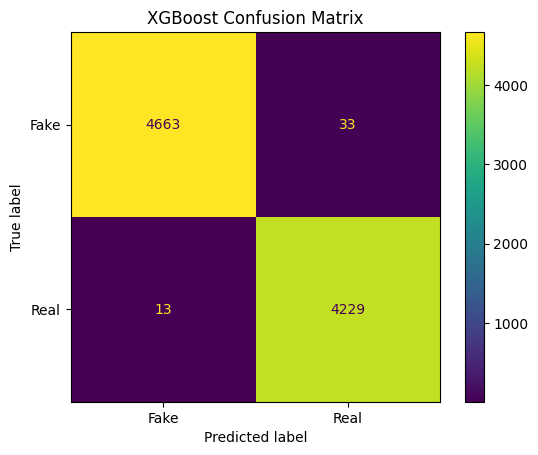

In [6]:
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    xgboost,
    X_test_tfidf,
    Y_test,
    display_labels=['Fake', 'Real'],
    )
plt.title("XGBoost Confusion Matrix")
plt.show()



In [7]:
#save model of choice
import joblib

joblib.dump(xgboost, "xgboost_fake_news_model.pkl")
joblib.dump(vect, "tfidf_vectorizer.pkl")




['tfidf_vectorizer.pkl']

In [8]:
from google.colab import files

# Download the files
files.download("xgboost_fake_news_model.pkl")
files.download("tfidf_vectorizer.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import web_scraping_and_cleaning_functions as sc_fn
import requests
from bs4 import BeautifulSoup
import re
import json
from urllib.parse import quote
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download("punkt_tab")
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [24]:
def clean_content(text):
    text = str(text).strip().lower()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    lemmatized = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(lemmatized)

#  fetch from archived version if live page is not accessible
def wayback_fetch(url, headers):
    """Try to fetch the closest archived snapshot from the Wayback Machine."""
    api = f"https://archive.org/wayback/available?url={quote(url)}"
    r = requests.get(api, headers=headers, timeout=10)
    r.raise_for_status()
    data = r.json()
    snap = data.get("archived_snapshots", {}).get("closest")
    if not snap or not snap.get("available"):
        raise requests.exceptions.RequestException("No archived snapshot available")
    snapshot_url = snap.get("url")
    rs = requests.get(snapshot_url, headers=headers, timeout=15)
    rs.raise_for_status()
    return BeautifulSoup(rs.text, "html.parser")


def scrape_article(url):
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        )
    }

    # fetch website
    soup = None
    try:
        res = requests.get(url, headers=headers, timeout=15)
        res.raise_for_status()
        soup = BeautifulSoup(res.text, "html.parser")
    except requests.exceptions.RequestException:
        try:
            soup = wayback_fetch(url, headers)
        except requests.exceptions.RequestException:
          raise RuntimeError(f"Please try another link.")

    # try to detect JSON data (for sites like NBC, CNN, etc.)
    script_tag = soup.find("script", text=re.compile(r"window\.__data\s*="))
    if script_tag and script_tag.string:
        try:
            json_text = re.search(r"window\.__data\s*=\s*({.*});", script_tag.string).group(1)
            data = json.loads (json_text)
            # Try to find generic fields like headline/description/transcript
            title = data.get("initialState", {}).get("video", {}).get("currentVideo", {}).get("headline")
            body = (
                data.get("initialState", {}).get("video", {}).get("currentVideo", {}).get("description", "")
                + "\n"
                + data.get("initialState", {}).get("video", {}).get("currentVideo", {}).get("transcript", "")
            )
            if title and body:
                return title, clean_text(body)
        except Exception:
            pass

    # find title using common tags
    title_candidates = [
        soup.find("h1"),
        soup.find("meta", property="og:title"),
        soup.find("meta", attrs={"name": "twitter:title"}),
    ]
    title = next(
        (t.get_text(strip=True) if hasattr(t, "get_text") else t["content"])
        for t in title_candidates
        if t
    ) if any(title_candidates) else "(No title found)"

    # collect paragraphs from likely article sections
    body_candidates = [
        "article",
        "main",
        "div[class*='article']",
        "div[class*='content']",
        "div[itemprop='articleBody']",
        "section[name='articleBody']",
    ]

    paragraphs = []
    for selector in body_candidates:
        elements = soup.select(selector + " p")
        if elements:
            paragraphs = elements
            break

    if not paragraphs:
        paragraphs = soup.find_all("p")

    body_text = "\n".join(p.get_text(strip=True) for p in paragraphs)
    return title, clean_text(body_text)


def clean_text(text):
    """Remove irrelevant or boilerplate lines commonly found in news sites."""
    bad_phrases = [
        "news alerts",
        "breaking news",
        "there are no new alerts",
        "©",
        "sign up",
        "subscribe",
        "follow us",
        "advertisement",
        "read more",
        "all rights reserved",
        "supported by"
    ]

    cleaned_lines = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        lower_line = line.lower()
        if any(bad in lower_line for bad in bad_phrases):
            continue
        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)


def scrape_and_clean_article(url):
    title, body = scrape_article(url)
    all_text = title + ' ' + body
    cleaned_text = clean_content(all_text)
    return cleaned_text




In [ ]:
import os
os.environ['OPENAI_API_KEY']="your_openai_api_key_here"  # replace with your OpenAI API key

In [ ]:
# =========================================================
# LOAD MODEL & OPENAI CLIENT
# =========================================================

model = joblib.load("xgboost_fake_news_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

client = OpenAI(api_key="your_openai_api_key_here")  # replace with your OpenAI API key


# =========================================================
# CHATGPT FACT-CHECKING FUNCTION
# =========================================================

def ask_chatgpt(text):
    """
    Sends text to ChatGPT and asks: Real or Fake?
    """
    prompt = f"""
You are a fact-checking model.
Analyze the following news text and classify it as either REAL or FAKE.
Also provide a confidence level (0–100%).

Text:
{text}

Respond ONLY in this JSON format:
{{
  "classification": "Real" or "Fake",
  "confidence": <number 0-100>
}}
"""

    response = client.responses.create(
        model="gpt-4.1-mini",
        input=prompt,
        temperature=0
    )

    content = response.output_text.strip()

    import json
    try:
        data = json.loads(content)
        classification = data.get("classification", "Unknown")
        confidence = data.get("confidence", 0)
    except:
        classification = "Unknown"
        confidence = 0

    return classification, confidence


# =========================================================
# MAIN PREDICTION FUNCTION — URL → TEXT → MODEL
# =========================================================

def predict_news(url):
    """Accepts a URL, scrapes the article, cleans it, then predicts."""
    if not url.strip():
        return "⚠️ Please enter a URL."

    # ---- SCRAPE & CLEAN ----
    try:
        cleaned_text = scrape_and_clean_article(url)  # (you already defined this)
    except Exception as e:
        return f"❌ Error scraping article: {e}"

    # ---- XGBoost prediction ----
    X_input = vectorizer.transform([cleaned_text])
    pred = model.predict(X_input)[0]

    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X_input)[0]
        model_conf = proba[pred] * 100
    else:
        model_conf = None

    model_label = "Real" if pred == 1 else "Fake"

    # ---- ChatGPT prediction ----
    gpt_label, gpt_conf = ask_chatgpt(cleaned_text)

    # ---- Format output ----
    output = "### 🔍 XGBoost Model Prediction\n"
    output += f"**Result:** {'🟢 Real News' if model_label=='Real' else '🔴 Fake News'}\n"
    if model_conf is not None:
        output += f"**Confidence:** {model_conf:.2f}%\n\n"

    output += "### 🤖 ChatGPT Prediction\n"
    icon = "🟢" if gpt_label.lower() == "real" else "🔴"
    output += f"**Result:** {icon} {gpt_label} News\n"
    output += f"**Confidence:** {gpt_conf:.2f}%\n"

    return output


# =========================================================
# GRADIO DASHBOARD
# =========================================================

demo = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(
        label="Enter a News URL",
        placeholder="Paste a URL to a news article...",
        lines=2,
    ),
    outputs=gr.Markdown(label="Prediction Results"),
    title="📰 Fake News Detector (URL-Based)",
    description="Paste a URL. The system automatically scrapes, cleans, and classifies the article as Real or Fake.",
)

if __name__ == "__main__":
    demo.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6450dc12f3ac7e3b06.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
